In [16]:
# Set working directory to project root and select device (GPU if available)
import os
import torch
# change this path if your project root is elsewhere
proj_root = r"c:\Users\piyus\PG-learning\learning-repo"
os.chdir(proj_root)
print('cwd ->', os.getcwd())
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Selected device:', device)
# show GPU name when available
if device.type == 'cuda':
    try:
        print('CUDA name:', torch.cuda.get_device_name(0))
    except Exception as e:
        print('Could not query CUDA device name:', e)

# small torch sanity check
x = torch.randn(3, device=device)
print('Tensor device:', x.device)

# IMPORTANT: Change working directory to avoid conflict with model name
# Since we're in a directory called 'gpt2', transformers thinks we want to load from local files
import os
print(f"Current directory before change: {os.getcwd()}")
# Go up one level to avoid the naming conflict
parent_dir = os.path.dirname(os.getcwd())
os.chdir(parent_dir)
print(f"Changed working directory to: {os.getcwd()}")

cwd -> c:\Users\piyus\PG-learning\learning-repo
Selected device: cuda
CUDA name: NVIDIA GeForce RTX 3050 Laptop GPU
Tensor device: cuda:0
Current directory before change: c:\Users\piyus\PG-learning\learning-repo
Changed working directory to: c:\Users\piyus\PG-learning


In [10]:
from transformers import GPT2LMHeadModel

c:\Users\piyus\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [29]:
model_hf = GPT2LMHeadModel.from_pretrained("gpt2")# 124m param model
sd_hf = model_hf.state_dict() # raw tensors of the dictionary 

for k,v in sd_hf.items():
    print(k,v.shape)

transformer.wte.weight torch.Size([50257, 768])
transformer.wpe.weight torch.Size([1024, 768])
transformer.h.0.ln_1.weight torch.Size([768])
transformer.h.0.ln_1.bias torch.Size([768])
transformer.h.0.attn.c_attn.weight torch.Size([768, 2304])
transformer.h.0.attn.c_attn.bias torch.Size([2304])
transformer.h.0.attn.c_proj.weight torch.Size([768, 768])
transformer.h.0.attn.c_proj.bias torch.Size([768])
transformer.h.0.ln_2.weight torch.Size([768])
transformer.h.0.ln_2.bias torch.Size([768])
transformer.h.0.mlp.c_fc.weight torch.Size([768, 3072])
transformer.h.0.mlp.c_fc.bias torch.Size([3072])
transformer.h.0.mlp.c_proj.weight torch.Size([3072, 768])
transformer.h.0.mlp.c_proj.bias torch.Size([768])
transformer.h.1.ln_1.weight torch.Size([768])
transformer.h.1.ln_1.bias torch.Size([768])
transformer.h.1.attn.c_attn.weight torch.Size([768, 2304])
transformer.h.1.attn.c_attn.bias torch.Size([2304])
transformer.h.1.attn.c_proj.weight torch.Size([768, 768])
transformer.h.1.attn.c_proj.bias 

In [18]:
sd_hf["transformer.wpe.weight"].view(-1)[:20] #flattened weights of positional embeds

tensor([-0.0188, -0.1974,  0.0040,  0.0113,  0.0638, -0.1050,  0.0369, -0.1680,
        -0.0491, -0.0565, -0.0025,  0.0135, -0.0042,  0.0151,  0.0166, -0.1381,
        -0.0063, -0.0461,  0.0267, -0.2042])

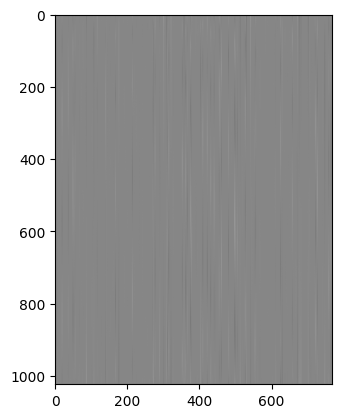

In [19]:
import matplotlib.pyplot as plt
%matplotlib inline
plt.imshow(sd_hf["transformer.wpe.weight"],cmap="gray")

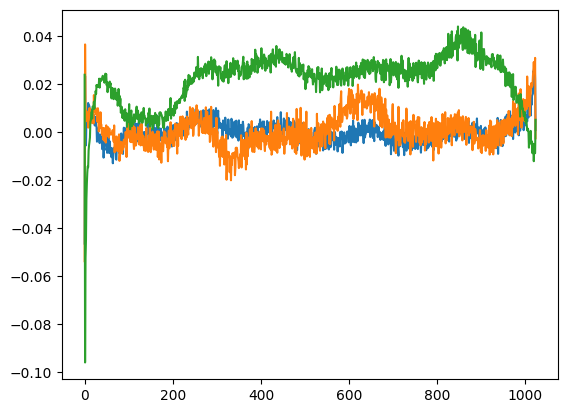

In [20]:
plt.plot(sd_hf["transformer.wpe.weight"][:,150])
plt.plot(sd_hf["transformer.wpe.weight"][:,200])
plt.plot(sd_hf["transformer.wpe.weight"][:,250])


### the more smooth the above position embeddings weights looks the better its trained , so this isnt the best trained model ......

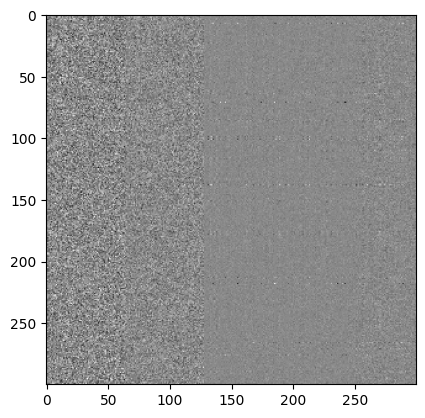

In [21]:
plt.imshow(sd_hf["transformer.h.1.attn.c_attn.weight"][:300,:300],cmap = "gray")#layer 1

In [22]:
from transformers import pipeline, set_seed           # sampling the model 
generator = pipeline('text-generation', model='gpt2')
set_seed(42)
outs = generator('hello , I.m a language model', max_length=30, num_return_sequences=5)
for i, o in enumerate(outs, 1):
    print(f'--- sample {i} ---')
    print(o['generated_text'])

Device set to use cuda:0
Truncation was not explicitly activated but `max_length` is provided a specific value, please use `truncation=True` to explicitly truncate examples to max length. Defaulting to 'longest_first' truncation strategy. If you encode pairs of sequences (GLUE-style) with the tokenizer you can select this strategy more precisely by providing a specific strategy to `truncation`.
Truncation was not explicitly activated but `max_length` is provided a specific value, please use `truncation=True` to explicitly truncate examples to max length. Defaulting to 'longest_first' truncation strategy. If you encode pairs of sequences (GLUE-style) with the tokenizer you can select this strategy more precisely by providing a specific strategy to `truncation`.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Both `max_new_tokens` (=256) and `max_length`(=30) seem to have been set. `max_new_to

--- sample 1 ---
hello , I.m a language model for the problem. When it comes to the problem, the solution is the same as the previous one:

import Data.Into.Lazy as Lazy val code = lazy.Lazy() println(code)

The problem is:

Code is a lazy class that will be called on every data type. If you create a class with this class, it will be called by the constructor of the class that generated the data type.

Let's see how to create the code of this class:

import Data.Into.Lazy.Lazy as Lazy val code = lazy.Lazy() println(code)

The last line is the constructor of the class.

import Data.Into.Lazy.Lazy.Lazy.Lazy val code = lazy.Lazy() println(code)

The code is a lazy class that will be called by the constructor of the class that generated the data type.

The last line is the constructor of the class.

So, let's see how to build our data model for the problem:

import Data.Into.Lazy.Lazy import Data.Into.Lazy.
--- sample 2 ---
hello , I.m a language model that can be modified by calling the c

In [25]:
# tiny shakespeare dataset 
with open(r'C:\Users\piyus\PG-learning\learning-repo\gpt2\input.txt','r') as f:
    text = f.read()
data = text[:1000] # first 1000 characters gpt 2 has conversion ratio of 3:1 i.e characters generally means 1 tokens 
print(data[:100])

First Citizen:
Before we proceed any further, hear me speak.

All:
Speak, speak.

First Citizen:
You


In [26]:
import tiktoken
enc = tiktoken.get_encoding('gpt2')
tokens = enc.encode(data)
print(tokens[:24])

[5962, 22307, 25, 198, 8421, 356, 5120, 597, 2252, 11, 3285, 502, 2740, 13, 198, 198, 3237, 25, 198, 5248, 461, 11, 2740, 13]


In [27]:
import torch 
buf = torch.tensor(tokens[:24+1]) # b*t+1
x = buf[:-1].view(4,6)
y = buf[1:].view(4,6)
print(x)  # just getting a 2d view
print(y)

tensor([[ 5962, 22307,    25,   198,  8421,   356],
        [ 5120,   597,  2252,    11,  3285,   502],
        [ 2740,    13,   198,   198,  3237,    25],
        [  198,  5248,   461,    11,  2740,    13]])
tensor([[22307,    25,   198,  8421,   356,  5120],
        [  597,  2252,    11,  3285,   502,  2740],
        [   13,   198,   198,  3237,    25,   198],
        [ 5248,   461,    11,  2740,    13,   198]])


In [30]:
print(sd_hf["lm_head.weight"].shape) # head of the transfomeer
print(sd_hf["transformer.wte.weight"].shape) # tail of the transformer

torch.Size([50257, 768])
torch.Size([50257, 768])


In [31]:
(sd_hf["lm_head.weight"] == sd_hf["transformer.wte.weight"]).all()

tensor(True)

In [32]:
print(sd_hf["lm_head.weight"].data_ptr())
print(sd_hf)

2955204997075
OrderedDict({'transformer.wte.weight': tensor([[-0.1101, -0.0393,  0.0331,  ..., -0.1364,  0.0151,  0.0453],
        [ 0.0403, -0.0486,  0.0462,  ...,  0.0861,  0.0025,  0.0432],
        [-0.1275,  0.0479,  0.1841,  ...,  0.0899, -0.1297, -0.0879],
        ...,
        [-0.0445, -0.0548,  0.0123,  ...,  0.1044,  0.0978, -0.0695],
        [ 0.1860,  0.0167,  0.0461,  ..., -0.0963,  0.0785, -0.0225],
        [ 0.0514, -0.0277,  0.0499,  ...,  0.0070,  0.1552,  0.1207]]), 'transformer.wpe.weight': tensor([[-1.8821e-02, -1.9742e-01,  4.0267e-03,  ..., -4.3044e-02,
          2.8267e-02,  5.4490e-02],
        [ 2.3959e-02, -5.3792e-02, -9.4879e-02,  ...,  3.4170e-02,
          1.0172e-02, -1.5573e-04],
        [ 4.2161e-03, -8.4764e-02,  5.4515e-02,  ...,  1.9745e-02,
          1.9325e-02, -2.1424e-02],
        ...,
        [-1.7987e-03,  1.6052e-03, -5.5103e-02,  ...,  1.3617e-02,
         -7.1805e-03,  3.7552e-03],
        [ 3.2105e-03,  1.5501e-03, -4.8944e-02,  ...,  2.0725

In [34]:
# standard deviation grows inside the residual stream 
x = torch.zeros(768)
n = 100 # number of layes
for i in range(n):
    x += n**-0.5*torch.randn(768)
    
print(x.std())

tensor(1.0324)
